In [31]:
import pandas as pd
import numpy as np


In [32]:
df=pd.read_csv("House Price Prediction Dataset.csv")

In [33]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [34]:
df.isnull

<bound method DataFrame.isnull of         Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fa

In [35]:
df.isnull().sum

<bound method DataFrame.sum of          Id   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  \
0     False  False     False      False   False      False     False   
1     False  False     False      False   False      False     False   
2     False  False     False      False   False      False     False   
3     False  False     False      False   False      False     False   
4     False  False     False      False   False      False     False   
...     ...    ...       ...        ...     ...        ...       ...   
1995  False  False     False      False   False      False     False   
1996  False  False     False      False   False      False     False   
1997  False  False     False      False   False      False     False   
1998  False  False     False      False   False      False     False   
1999  False  False     False      False   False      False     False   

      Condition  Garage  Price  
0         False   False  False  
1         False   False  False  
2    

In [36]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool>

In [37]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [39]:
df.drop(["Id"],axis=1)  

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1062,5,1,2,1903,Rural,Poor,No,476925
1998,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [40]:
x=df[["Area","Bedrooms","Bathrooms","Floors","YearBuilt"]]
y=df["Price"]

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
import matplotlib.pyplot as plt

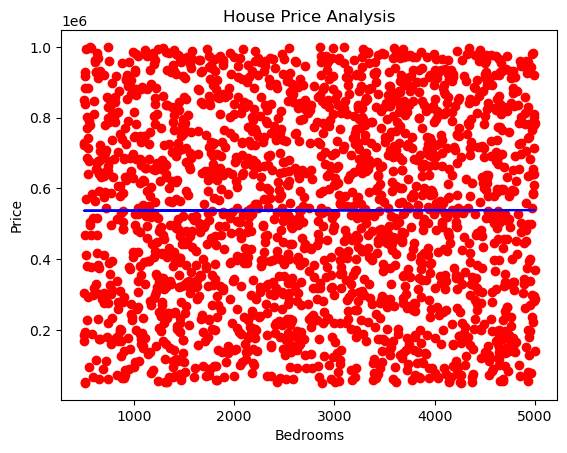

In [43]:
x = df[['Area']]      
y = df['Price']      

lin_reg = LinearRegression()
lin_reg.fit(x, y)

plt.scatter(x, y, color="red")
plt.plot(x, lin_reg.predict(x), color="blue")

plt.title("House Price Analysis")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)


train_pred=lin_reg.predict(x_train)
test_pred=lin_reg.predict(x_test)

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [47]:
rmse_train=np.sqrt(mean_squared_error(y_train,train_pred))
rmse_test=np.sqrt(mean_squared_error(y_test,test_pred))


In [48]:
rmse_train

np.float64(275694.5111545402)

In [49]:
rmse_test

np.float64(279027.1086887075)

In [50]:
mae_train=mean_absolute_error(y_train,train_pred)
mae_test=mean_absolute_error(y_test,test_pred)

In [51]:
mae_train

238196.98665679814

In [52]:
mae_test

242478.32249473498

In [53]:
r_squre_train=r2_score(y_train,train_pred)

In [54]:
r_squre_train

7.52495507683193e-07

In [55]:
r_squre_test=r2_score(y_test,test_pred)

In [56]:
r_squre_test

-0.0007365003351658128

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf=RandomForestClassifier(n_estimators=200)
rf.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of sa

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
